In [1]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# Set the project root for notebook execution.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
from ml.preprocessing import preprocess_text

In [2]:
# Load the support ticket data.
df = pd.read_csv(PROJECT_ROOT / "dataset/customer_support_data.csv")
df.head()

,Ticket_ID,Customer_Name,Customer_Email,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Submission_Date,Resolution_Time_Hours,Assigned_Agent,Satisfaction_Score
0,TKT-100000,George Simon,lisastrickland@example.com,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,High,Web Form,2025-07-02,43,David Kim,5
1,TKT-100001,Scott Thompson,wevans@example.org,Data not syncing - Card,"Hi Support, The application crashes every time...",Technical,High,Chat,2025-06-28,41,Elena Rodriguez,5
2,TKT-100002,Jennifer Smith,oleonard@example.net,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...",Account,High,Web Form,2025-02-05,7,Anya Sharma,5
3,TKT-100003,Rachel Bullock,katherine67@example.net,Login failed - Let,"Hi Support, The dashboard is not loading any d...",Technical,Low,Web Form,2025-03-20,41,Anya Sharma,5
4,TKT-100004,Thomas Parks DDS,raykelsey@example.com,Refund status - Attention,"Hi Support, I have been trying to update my pa...",Billing,Medium,Email,2025-04-27,40,David Kim,5


In [3]:
# Clean missing values and remove unusable rows.
text_columns = ["Ticket_Subject", "Ticket_Description"]
target_columns = ["Issue_Category", "Priority_Level"]
df[text_columns + target_columns] = df[text_columns + target_columns].fillna("")
df = df[(df["Issue_Category"].str.strip() != "") & (df["Priority_Level"].str.strip() != "")].copy()
df["combined_text"] = df["Ticket_Subject"].astype(str) + " " + df["Ticket_Description"].astype(str)
df["clean_text"] = df["combined_text"].apply(preprocess_text)
df = df[df["clean_text"].str.strip() != ""].copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Ticket_ID              20000 non-null  object
 1   Customer_Name          20000 non-null  object
 2   Customer_Email         20000 non-null  object
 3   Ticket_Subject         20000 non-null  object
 4   Ticket_Description     20000 non-null  object
 5   Issue_Category         20000 non-null  object
 6   Priority_Level         20000 non-null  object
 7   Ticket_Channel         20000 non-null  object
 8   Submission_Date        20000 non-null  object
 9   Resolution_Time_Hours  20000 non-null  int64 
 10  Assigned_Agent         20000 non-null  object
 11  Satisfaction_Score     20000 non-null  int64 
 12  combined_text          20000 non-null  object
 13  clean_text             20000 non-null  object
dtypes: int64(2), object(12)
memory usage: 2.1+ MB


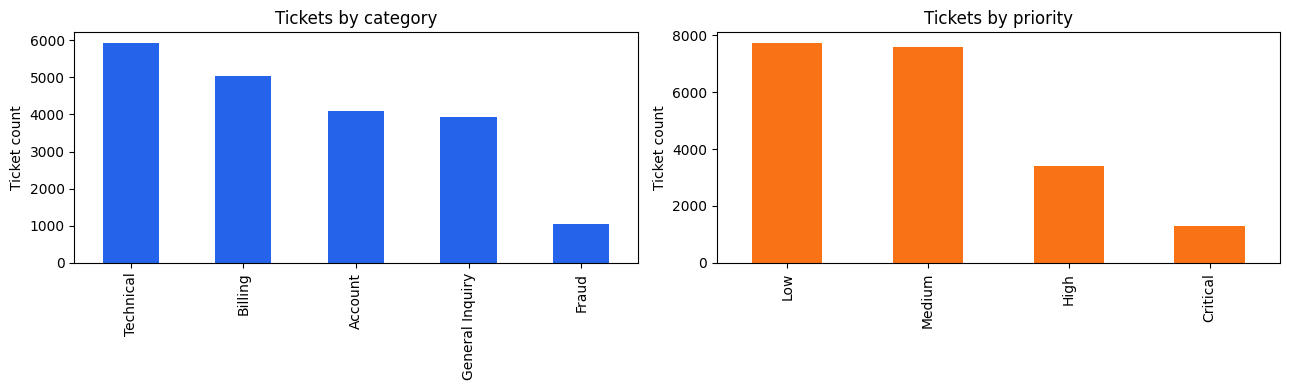

In [4]:
# Visualize category and priority balance.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df["Issue_Category"].value_counts().plot.bar(ax=axes[0], color="#2563eb", title="Tickets by category")
df["Priority_Level"].value_counts().plot.bar(ax=axes[1], color="#f97316", title="Tickets by priority")
for axis in axes:
    axis.set_xlabel("")
    axis.set_ylabel("Ticket count")
plt.tight_layout()
plt.show()

In [5]:
# Split text and labels for both models.
X = df["clean_text"]
y_category = df["Issue_Category"]
y_priority = df["Priority_Level"]
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(X, y_category, test_size=0.20, random_state=42, stratify=y_category)
X_train_pri, X_test_pri, y_train_pri, y_test_pri = train_test_split(X, y_priority, test_size=0.20, random_state=42, stratify=y_priority)

Category accuracy: 1.0
                 precision    recall  f1-score   support

        Account       1.00      1.00      1.00       816
        Billing       1.00      1.00      1.00      1007
          Fraud       1.00      1.00      1.00       208
General Inquiry       1.00      1.00      1.00       785
      Technical       1.00      1.00      1.00      1184

       accuracy                           1.00      4000
      macro avg       1.00      1.00      1.00      4000
   weighted avg       1.00      1.00      1.00      4000



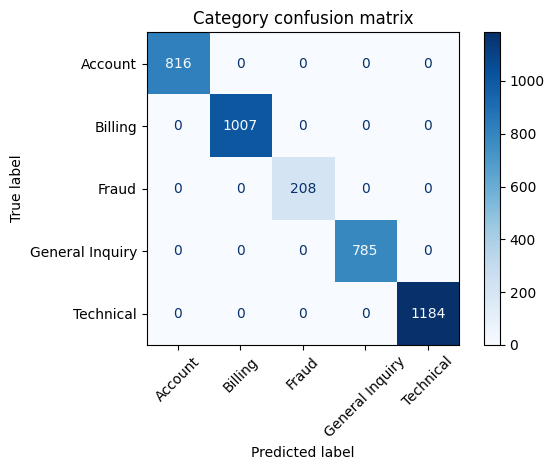

In [6]:
# Train and evaluate the category model.
category_vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)
X_cat_train_vec = category_vectorizer.fit_transform(X_train_cat)
X_cat_test_vec = category_vectorizer.transform(X_test_cat)
category_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
category_model.fit(X_cat_train_vec, y_train_cat)
cat_preds = category_model.predict(X_cat_test_vec)
print("Category accuracy:", round(accuracy_score(y_test_cat, cat_preds), 4))
print(classification_report(y_test_cat, cat_preds))
ConfusionMatrixDisplay.from_predictions(y_test_cat, cat_preds, xticks_rotation=45, cmap="Blues")
plt.title("Category confusion matrix")
plt.tight_layout()
plt.show()

Priority accuracy: 0.4028
              precision    recall  f1-score   support

    Critical       0.36      0.66      0.46       260
        High       0.29      0.35      0.32       683
         Low       0.48      0.57      0.52      1543
      Medium       0.37      0.21      0.27      1514

    accuracy                           0.40      4000
   macro avg       0.38      0.45      0.39      4000
weighted avg       0.40      0.40      0.39      4000



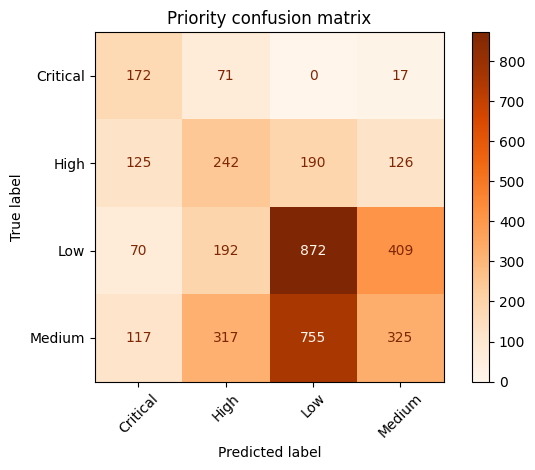

In [7]:
# Train and evaluate the priority model.
priority_vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)
X_pri_train_vec = priority_vectorizer.fit_transform(X_train_pri)
X_pri_test_vec = priority_vectorizer.transform(X_test_pri)
priority_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
priority_model.fit(X_pri_train_vec, y_train_pri)
pri_preds = priority_model.predict(X_pri_test_vec)
print("Priority accuracy:", round(accuracy_score(y_test_pri, pri_preds), 4))
print(classification_report(y_test_pri, pri_preds))
ConfusionMatrixDisplay.from_predictions(y_test_pri, pri_preds, xticks_rotation=45, cmap="Oranges")
plt.title("Priority confusion matrix")
plt.tight_layout()
plt.show()

In [8]:
# Save trained models for the Flask app.
joblib.dump(category_model, PROJECT_ROOT / "models/category_model.pkl")
joblib.dump(category_vectorizer, PROJECT_ROOT / "models/category_vectorizer.pkl")
joblib.dump(priority_model, PROJECT_ROOT / "models/priority_model.pkl")
joblib.dump(priority_vectorizer, PROJECT_ROOT / "models/priority_vectorizer.pkl")
print("Category and priority models saved.")

Category and priority models saved.
